In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import confusion_matrix

In [2]:
transform = transforms.ToTensor()

In [3]:
train_data = datasets.MNIST(root='../Data',train=True,download=True,transform=transform)

In [4]:
test_data = datasets.MNIST(root='../Data',train=False,download=True,transform=transform)

In [5]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [7]:
train_loader = DataLoader(train_data,batch_size=10,shuffle=True)

In [8]:
test_loader = DataLoader(test_data,batch_size=10,shuffle=False)

In [14]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,6,3,1)
        self.conv2 = nn.Conv2d(6,16,3,1)
        self.fc1 = nn.Linear(5*5*16,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

    def forward(self,X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X,2,2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X,2,2)
        X = X.view(-1,5*5*16)
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return F.log_softmax(X,dim=1)

In [15]:
torch.manual_seed(13)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [21]:
import time
start_time = time.time()

epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0

    for b,(X_train,y_train) in enumerate(train_loader):
        b+=1

        y_pred = model(X_train)
        loss = criterion(y_pred,y_train)

        predicted = torch.max(y_pred.data,1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b%600 == 0:
             print(f'epoch: {i:2}  batch: {b:4} [{10*b:6}/60000]  loss: {loss.item():10.8f}  \
accuracy: {trn_corr.item()*100/(10*b):7.3f}%')

    train_losses.append(loss.item())
    train_correct.append(trn_corr.item())

    with torch.no_grad():
        for b,(X_test,y_test) in enumerate (test_loader):
            y_val = model(X_test)

            predicted = torch.max(y_val.data,1)[1]
            tst_corr += (predicted == y_test)

        loss = criterion(y_val,y_test)
        test_losses.append(loss)
        test_correct.append(tst_corr)


print(f"\nDuration: {time.time() - start_time:.0f} Seconds")

epoch:  0  batch:  600 [  6000/60000]  loss: 0.01946874  accuracy:  97.667%
epoch:  0  batch: 1200 [ 12000/60000]  loss: 0.00100050  accuracy:  97.508%
epoch:  0  batch: 1800 [ 18000/60000]  loss: 0.14347038  accuracy:  97.633%
epoch:  0  batch: 2400 [ 24000/60000]  loss: 0.00506219  accuracy:  97.688%
epoch:  0  batch: 3000 [ 30000/60000]  loss: 0.00505696  accuracy:  97.780%
epoch:  0  batch: 3600 [ 36000/60000]  loss: 0.00564025  accuracy:  97.867%
epoch:  0  batch: 4200 [ 42000/60000]  loss: 0.01960545  accuracy:  97.914%
epoch:  0  batch: 4800 [ 48000/60000]  loss: 0.05192769  accuracy:  97.921%
epoch:  0  batch: 5400 [ 54000/60000]  loss: 0.22830649  accuracy:  97.950%
epoch:  0  batch: 6000 [ 60000/60000]  loss: 0.00617030  accuracy:  97.955%
epoch:  1  batch:  600 [  6000/60000]  loss: 0.00179424  accuracy:  98.483%
epoch:  1  batch: 1200 [ 12000/60000]  loss: 0.01526909  accuracy:  98.475%
epoch:  1  batch: 1800 [ 18000/60000]  loss: 0.16009827  accuracy:  98.461%
epoch:  1  b

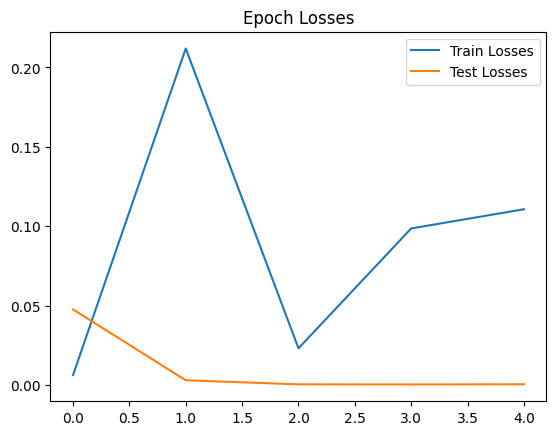

In [22]:
plt.plot(train_losses, label="Train Losses")
plt.plot(test_losses, label="Test Losses")
plt.title("Epoch Losses")
plt.legend()

In [26]:
new = DataLoader(test_data,batch_size=10000,shuffle=False)

with torch.no_grad():
    correct = 0
    for X_test,y_test in new:
        y_val = model(X_test)
        predicted = torch.max(y_val.data, 1)[1]
        correct += (predicted == y_test).sum()
print(f'Test accuracy: {correct.item()}/{len(test_data)} = {correct.item()*100/(len(test_data)):7.3f}%')

Test accuracy: 9878/10000 =  98.780%
